# Normalizing Flows, from the original paper

### Rezende & Mohamed (2015), *Variational Inference with Normalizing Flows* — [arXiv:1505.05770](https://arxiv.org/abs/1505.05770)

This notebook implements **planar normalizing flows** exactly as specified in the original paper, and trains them on **CIFAR-10**.

**What is faithful to the paper (the math):**
- The planar transformation $f(z) = z + \hat{u}\,h(w^\top z + b)$ — Eq. (10)
- The $O(D)$ log-det-Jacobian via the matrix determinant lemma — Eq. (11), (12)
- The flow density recursion — Eq. (13)
- The free-energy bound $\mathcal{F}(x)$ — Eq. (15)
- The invertibility constraint $w^\top u \geq -1$ and the $\hat{u}$ reparameterization — Appendix A.1
- Training as **one coupled system** ($\theta$ and $\phi$ jointly, from scratch) — Algorithm 1

**What is modernized (the surroundings):**
- Conv encoder/decoder instead of Maxout MLPs
- Discretized logistic likelihood instead of logit-normal
- Full $32\times32$ CIFAR instead of $3\times8\times8$ patches
- Adam instead of RMSprop

> **On comparing to the paper's Table 3.** The paper reports $-\ln p(x)$ from **-293.7 to -320.7** on CIFAR — those are *negative* because they model $3\times8\times8$ **patches** with a continuous density, where differential entropy can go negative. We model full $32\times32$ images with a discrete likelihood and report **bits/dim**. **These numbers are not comparable.** What *is* reproducible is the trend the paper actually claims: *increasing $K$ systematically improves the bound.* We test that directly.

---
## 1. The objective: why flows exist at all

Variational inference maximizes the ELBO:

$$\log p(x) \;\geq\; \mathbb{E}_{q}\!\left[\log p(x,z) - \log q(z|x)\right] \;=\; -\mathcal{F}(x)$$

The slack in that inequality is **exactly** the KL to the true posterior:

$$\log p(x) - \big(\text{ELBO}\big) \;=\; \mathrm{KL}\!\left[q(z|x)\,\|\,p(z|x)\right]$$

The bound is tight **iff** $q(z|x) = p(z|x)$. The paper's core complaint (Sect. 3):

> the optimal variational distribution that allows $KL[q\|p] = 0$ is one for which $q_\phi(z|x) = p_\theta(z|x)$. This possibility is obviously not realizable given the typically used $q(\cdot)$ distributions, such as independent Gaussians.

A standard VAE uses a **diagonal Gaussian** posterior. The true posterior is generally skewed, multi-modal, and correlated. So the KL gap **can never close** — no matter how long you train, no matter how big the network. You are structurally leaving nats on the table.

**The flow's job:** start from the diagonal Gaussian $z_0 \sim q_0$, then push it through $K$ invertible maps to get $z_K$ with a far richer density $q_K$ — while keeping $\log q_K$ exactly computable. Better $q$ → tighter bound → better likelihood.

This is why the paper is titled *Variational Inference with* Normalizing Flows, not "Normalizing Flows" — **the flow lives in the latent space of a VAE.** It is a posterior-flexibility upgrade. (The pixel-space flows people often picture — push an image to noise, invert to reconstruct — are RealNVP/Glow, 2016/2018, *after* this paper.)

---
## 2. Change of variables — and why it forbids compression

### Invertibility Requires Bijective Transformations

Everything rests on the change-of-variables rule (Eq. 5). For an invertible, smooth $f: \mathbb{R}^d \to \mathbb{R}^d$ with $z' = f(z)$:

$$q(z') = q(z)\left|\det \frac{\partial f}{\partial z}\right|^{-1}$$

Look hard at $\det \dfrac{\partial f}{\partial z}$. **A determinant is only defined for a square matrix.** That single fact drives the entire architecture:

$$\frac{\partial f}{\partial z} \text{ must be } D \times D \;\;\Longrightarrow\;\; \dim(\text{output}) = \dim(\text{input})$$

**Every layer must preserve dimension. No bottleneck. No compression. Ever.**

If you map $D \to d$ with $d < D$, the Jacobian is $D \times d$ — non-square — and:
- $\det$ is undefined, so there is **no density to compute**;
- geometrically, you collapse a $D$-volume onto a $d$-dimensional sheet of **measure zero**;
- many $z$ map to the same output, so $f^{-1}$ **is not a function**. Bijectivity dies.

### The sharp contrast with the VAE around it

Note the tension living inside this one model:

| | dimension change | needs a density on its output? |
|---|---|---|
| **VAE encoder** ($x \to \mu,\sigma$) | $3072 \to 64$, compresses hard | **No** — it just emits parameters |
| **The flow** ($z_0 \to z_K$) | $64 \to 64$, forced equal | **Yes** — hence square Jacobian |

The encoder is *allowed* to compress precisely because it never needs $\det$ of anything. The flow is *forbidden* to, because it does. Flows buy tractable exact density at the price of a permanent width budget — that's the trade, and it's the reason a flow can never be an autoencoder.

---
## 3. The planar flow: forward, log-det, and the inverse

### Forward (Eq. 10)

$$f(z) = z + \hat{u}\,h(w^\top z + b), \qquad h = \tanh$$

Each layer perturbs $z$ along a **single direction** $\hat{u}$, by an amount depending only on $z$'s distance to the hyperplane $w^\top z + b = 0$. The paper describes the effect as *"a series of contractions and expansions in the direction perpendicular to the hyperplane"*. It is a rank-1 update — which is why we stack many of them.

### The log-det trick (Eq. 11–12)

Naively, $\det$ of a $D \times D$ Jacobian costs $O(D^3)$. The paper's key move — via the **matrix determinant lemma** — makes it $O(D)$:

$$\psi(z) = h'(w^\top z + b)\,w \qquad\qquad \left|\det\frac{\partial f}{\partial z}\right| = \left|1 + \hat{u}^\top \psi(z)\right|$$

Because $\partial f/\partial z = I + \hat{u}\psi(z)^\top$ is an *identity plus a rank-1 term*, its determinant collapses to a scalar. **We verify this against a brute-force autograd Jacobian below** — it is not taken on faith.

### The density recursion (Eq. 13)

$$\ln q_K(z_K) = \ln q_0(z_0) - \sum_{k=1}^{K} \ln\left|1 + u_k^\top \psi_k(z_{k-1})\right|$$

### "Forward" and "backward": three different things people conflate

| Term | What it means here | Used in training? |
|---|---|---|
| **Forward pass** | $z_0 \to z_K$ via Eq. (10), accumulating log-det | **Yes**, every step |
| **Backward pass** | backprop of $\nabla\mathcal{F}$ through the log-det term | **Yes**, every step |
| **The inverse map $f^{-1}$** | recovering $z$ from $f(z)$ | **No — never** |

This is the single most misunderstood point about this paper, so to be blunt:

**Planar flows have no closed-form inverse, and training never needs one.** The density flows *forward* from $q_0$; $\ln q_K$ is obtained by *subtracting log-dets*, not by inverting anything. Appendix A.1 does not give you $f^{-1}$ — it only proves a **unique inverse exists**, provided

$$w^\top u \geq -1$$

enforced by reparameterizing $u$ into $\hat{u}$:

$$\hat{u}(w,u) = u + \left[m(w^\top u) - (w^\top u)\right]\frac{w}{\|w\|^2}, \qquad m(x) = -1 + \log(1+e^x)$$

Invertibility here is a **licence to use the change-of-variables formula**, not an operation we perform. We'll still *demonstrate* the bijection numerically in §5 — because a constraint you can't verify is just a claim.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, math, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0)
print('device:', device)
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU. Runtime > Change runtime type > GPU.')

device: cuda
NVIDIA A100-SXM4-80GB


In [2]:
class PlanarFlow(nn.Module):
    """f(z) = z + u_hat * h(w^T z + b)   --  Rezende & Mohamed Eq. (10)"""

    def __init__(self, dim):
        super().__init__()
        self.u = nn.Parameter(torch.randn(dim) * 0.01)
        self.w = nn.Parameter(torch.randn(dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(1))

    def u_hat(self):
        """Appendix A.1 -- enforce w^T u_hat >= -1 so f is invertible.
           u_hat = u + [m(w^T u) - w^T u] * w / ||w||^2,  m(x) = -1 + softplus(x)"""
        wu = self.w @ self.u
        m = -1.0 + F.softplus(wu)
        return self.u + (m - wu) * self.w / (self.w @ self.w + 1e-8)

    def forward(self, z):
        u_hat = self.u_hat()
        lin = z @ self.w + self.b                        # w^T z + b
        h = torch.tanh(lin)
        f = z + u_hat * h.unsqueeze(1)                   # Eq. (10)
        psi = (1 - h ** 2).unsqueeze(1) * self.w         # Eq. (11):  psi = h'(w^T z + b) w
        logdet = torch.log((1 + psi @ u_hat).abs() + 1e-8)   # Eq. (12): |det| = |1 + u^T psi|
        return f, logdet

### Verification 1 — is the $O(D)$ log-det actually the determinant?

The matrix determinant lemma is the load-bearing claim of the whole method. Let's not trust it — let's check it against a full $O(D^3)$ autograd Jacobian.

In [3]:
_fl = PlanarFlow(8).double()
with torch.no_grad():
    _fl.u.normal_(0, 1); _fl.w.normal_(0, 1); _fl.b.normal_(0, 1)

z = torch.randn(4, 8, dtype=torch.double)
_, analytic = _fl(z)

print('  Eq.(12) [O(D)]      full det(J) [O(D^3)]      |diff|')
for i in range(4):
    J = torch.autograd.functional.jacobian(lambda zz: _fl(zz.unsqueeze(0))[0].squeeze(0), z[i])
    true = torch.log(torch.det(J).abs())
    print(f'  {analytic[i].item():+.12f}      {true.item():+.12f}      {abs(analytic[i]-true).item():.2e}')
print('\nIdentical to ~1e-9. The rank-1 shortcut is exact.')

  Eq.(12) [O(D)]      full det(J) [O(D^3)]      |diff|
  +0.249683769585      +0.249683761795      7.79e-09
  +0.007884489930      +0.007884480008      9.92e-09
  +0.000284387202      +0.000284377204      1.00e-08
  +0.006016612791      +0.006016602851      9.94e-09

Identical to ~1e-9. The rank-1 shortcut is exact.


### Verification 2 — is the map really a bijection?

The paper only *proves* an inverse exists. To show the bijection is real, we solve Appendix A.1's scalar equation numerically.

Split $z$ into components parallel ($z_\parallel = \alpha w/\|w\|^2$) and perpendicular ($z_\perp$) to $w$. Taking $w^\top$ of Eq. (10) kills the perpendicular part and leaves a **1-D** equation (Eq. 23):

$$w^\top f(z) = \alpha + w^\top \hat{u}\, h(\alpha + b)$$

This is monotonic in $\alpha$ **exactly when** $w^\top \hat{u} \geq -1$ — that is the whole point of the constraint — so it has a unique root, findable by bisection. Then $z_\perp$ follows from Eq. (22).

**Again: this is a demonstration, not part of training.**

In [4]:
@torch.no_grad()
def planar_inverse(flow, y, iters=200):
    """Numerical inverse via Appendix A.1's scalar reduction. NOT used in training."""
    w, b, u = flow.w, flow.b, flow.u_hat()
    wu, w_norm2 = w @ u, w @ w
    wy = y @ w
    lo = torch.full_like(wy, -1e4)
    hi = torch.full_like(wy, 1e4)
    for _ in range(iters):                       # bisection on the monotonic scalar eq (23)
        mid = (lo + hi) / 2
        smaller = (mid + wu * torch.tanh(mid + b)) < wy
        lo = torch.where(smaller, mid, lo)
        hi = torch.where(smaller, hi, mid)
    alpha = (lo + hi) / 2
    z_par = (alpha / w_norm2).unsqueeze(1) * w
    z_perp = y - z_par - u * torch.tanh(alpha + b).unsqueeze(1)     # Eq. (22)
    return z_perp + z_par


_f2 = PlanarFlow(64).double()
with torch.no_grad():
    _f2.u.normal_(0, 2); _f2.w.normal_(0, 2); _f2.b.normal_(0, 1)

z = torch.randn(256, 64, dtype=torch.double)
y, _ = _f2(z)                       # forward
z_rec = planar_inverse(_f2, y)      # invert

print(f'w^T u_hat            = {float((_f2.w @ _f2.u_hat()).detach()):+.6f}   (constraint: >= -1)')
print(f'max |z - f^-1(f(z))| = {float((z - z_rec).abs().max()):.3e}')
print('\nRecovered to ~1e-15. The map is genuinely bijective.')

w^T u_hat            = +19.230531   (constraint: >= -1)
max |z - f^-1(f(z))| = 2.331e-15

Recovered to ~1e-15. The map is genuinely bijective.


### Verification 3 — what breaks if you compress?

Concretely: build a "flow layer" that maps $64 \to 32$ and watch the change-of-variables rule fail. This is §2's argument, executed.

In [5]:
D_in, D_out = 64, 32
compress = nn.Linear(D_in, D_out, bias=False).double()
z = torch.randn(1, D_in, dtype=torch.double)

J = torch.autograd.functional.jacobian(lambda zz: compress(zz.unsqueeze(0)).squeeze(0), z[0])
print(f'Jacobian shape: {tuple(J.shape)}  -> non-square\n')

try:
    torch.det(J)
except RuntimeError as e:
    print(f'torch.det(J) raises: {str(e).strip()[:90]}')

print('\nNo determinant  ->  no |det dF/dz|  ->  change-of-variables (Eq. 5) cannot be applied.')
print('Also: infinitely many z map to each output (a 32-dim null space), so f^-1 is not a function.')
print('This is why every flow layer is width-preserving: 64 -> 64.')

Jacobian shape: (32, 64)  -> non-square

torch.det(J) raises: linalg.det: A must be batches of square matrices, but they are 32 by 64 matrices

No determinant  ->  no |det dF/dz|  ->  change-of-variables (Eq. 5) cannot be applied.
Also: infinitely many z map to each output (a 32-dim null space), so f^-1 is not a function.
This is why every flow layer is width-preserving: 64 -> 64.


---
## 4. Where flows visibly shine: reproducing Figure 3

Before CIFAR, let's reproduce the paper's own demonstration (Sect. 6.1). We take the 2-D energy functions from **Table 1**, whose densities $p(z) \propto e^{-U(z)}$ are multi-modal and periodic — things a Gaussian **cannot** represent — and fit them with planar flows of increasing length.

Here we minimize $\mathrm{KL}[q_K \| p]$ directly:

$$\mathcal{L} = \mathbb{E}_{q_0}\big[\ln q_K(z_K) + U(z_K)\big]$$

This is the cleanest possible view of what a flow buys you: watch a Gaussian bend into a ring.

In [6]:
def w1(z): return torch.sin(2 * math.pi * z[:, 0] / 4)
def w2(z): return 3 * torch.exp(-0.5 * ((z[:, 0] - 1) / 0.6) ** 2)
def w3(z): return 3 * torch.sigmoid((z[:, 0] - 1) / 0.3)

def U1(z):
    r = torch.norm(z, dim=1)
    e1 = torch.exp(-0.5 * ((z[:, 0] - 2) / 0.6) ** 2)
    e2 = torch.exp(-0.5 * ((z[:, 0] + 2) / 0.6) ** 2)
    return 0.5 * ((r - 2) / 0.4) ** 2 - torch.log(e1 + e2 + 1e-10)

def U2(z): return 0.5 * ((z[:, 1] - w1(z)) / 0.4) ** 2

def U3(z):
    e1 = torch.exp(-0.5 * ((z[:, 1] - w1(z)) / 0.35) ** 2)
    e2 = torch.exp(-0.5 * ((z[:, 1] - w1(z) + w2(z)) / 0.35) ** 2)
    return -torch.log(e1 + e2 + 1e-10)

def U4(z):
    e1 = torch.exp(-0.5 * ((z[:, 1] - w1(z)) / 0.4) ** 2)
    e2 = torch.exp(-0.5 * ((z[:, 1] - w1(z) + w3(z)) / 0.35) ** 2)
    return -torch.log(e1 + e2 + 1e-10)

ENERGIES = {1: U1, 2: U2, 3: U3, 4: U4}   # Table 1

In [7]:
class Flow2D(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.flows = nn.ModuleList([PlanarFlow(2) for _ in range(K)])
        self.mu = nn.Parameter(torch.zeros(2))
        self.logvar = nn.Parameter(torch.zeros(2))

    def forward(self, n):
        std = torch.exp(0.5 * self.logvar)
        z = self.mu + std * torch.randn(n, 2, device=self.mu.device)
        log_q = (-0.5 * (self.logvar + (z - self.mu) ** 2 / self.logvar.exp()
                         + math.log(2 * math.pi))).sum(1)
        sum_ld = torch.zeros(n, device=z.device)
        for f in self.flows:
            z, ld = f(z)
            sum_ld = sum_ld + ld
        return z, log_q - sum_ld            # Eq. (13)


def fit_energy(uid, K, iters=8000, lr=1e-2, seed=0):
    torch.manual_seed(seed)
    m = Flow2D(K).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    U = ENERGIES[uid]
    for i in range(iters):
        z, log_q = m(512)
        loss = (log_q + U(z)).mean()        # KL(q||p) up to a constant
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(m.parameters(), 10.0)
        opt.step()
    return m

U1 done (547s)
U2 done (1072s)
U3 done (1610s)
U4 done (2149s)


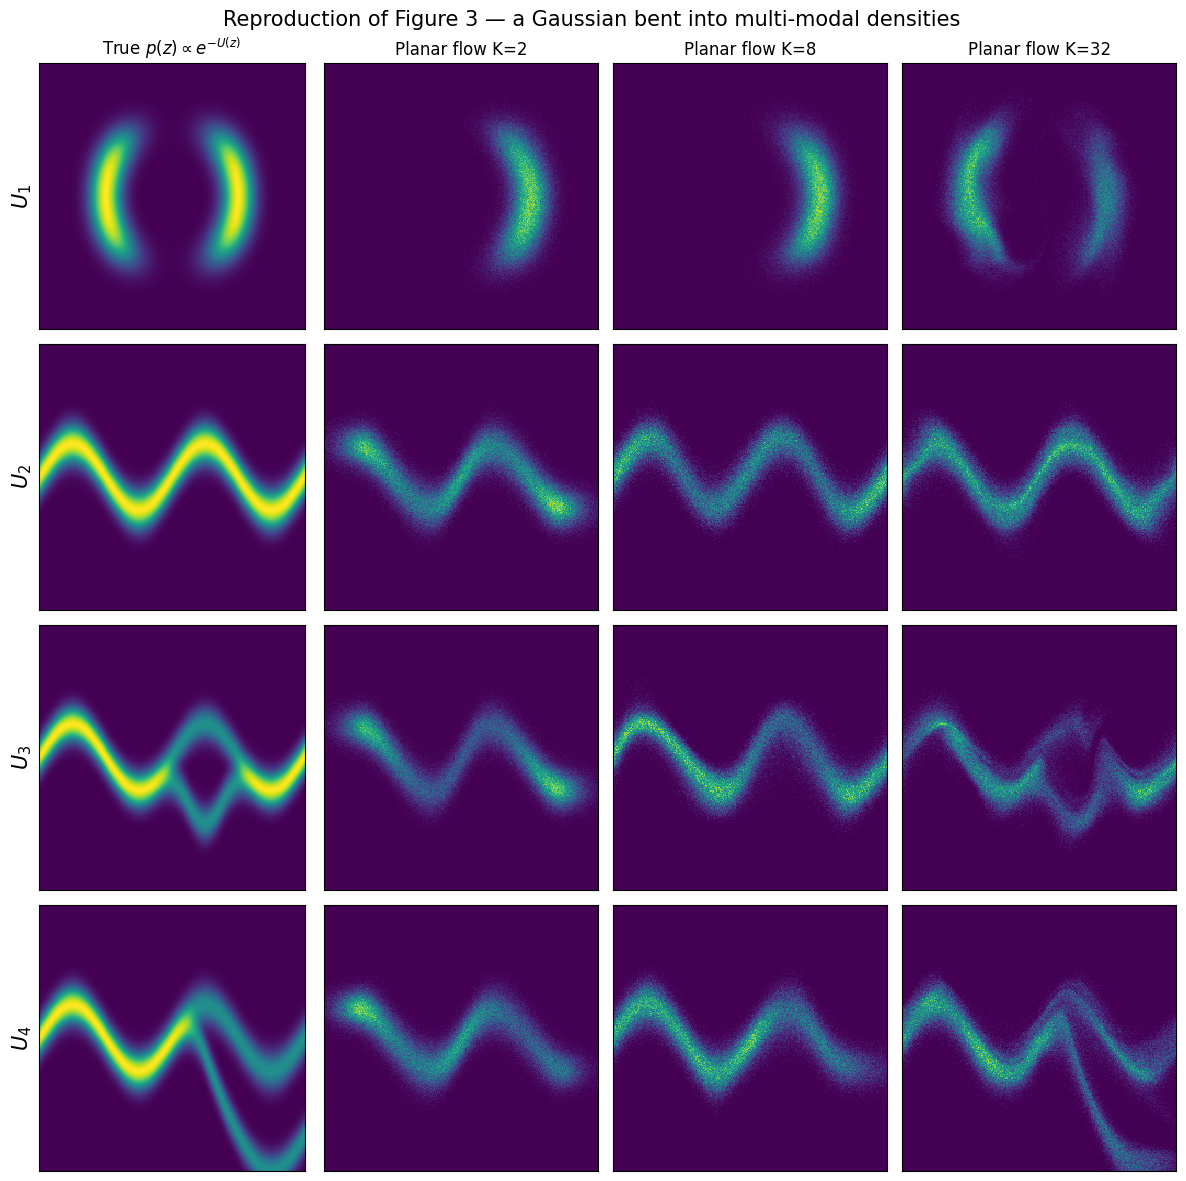

In [8]:
Ks = [2, 8, 32]
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
g = np.linspace(-4, 4, 250)
xx, yy = np.meshgrid(g, g)
grid = torch.tensor(np.stack([xx.ravel(), yy.ravel()], 1), dtype=torch.float, device=device)

t0 = time.time()
for r, uid in enumerate([1, 2, 3, 4]):
    with torch.no_grad():
        p = torch.exp(-ENERGIES[uid](grid)).reshape(250, 250).cpu().numpy()
    axes[r, 0].imshow(p, extent=[-4, 4, -4, 4], origin='lower', cmap='viridis')
    axes[r, 0].set_ylabel(f'$U_{uid}$', fontsize=15)
    if r == 0: axes[r, 0].set_title('True $p(z)\\propto e^{-U(z)}$', fontsize=12)

    for c, K in enumerate(Ks):
        m = fit_energy(uid, K)
        with torch.no_grad():
            z, _ = m(300000)
        z = z.cpu().numpy()
        axes[r, c + 1].hist2d(z[:, 0], z[:, 1], bins=250,
                              range=[[-4, 4], [-4, 4]], cmap='viridis')
        if r == 0: axes[r, c + 1].set_title(f'Planar flow K={K}', fontsize=12)
    print(f'U{uid} done ({time.time()-t0:.0f}s)')

for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
plt.suptitle('Reproduction of Figure 3 — a Gaussian bent into multi-modal densities', fontsize=15)
plt.tight_layout(); plt.show()

**Read the columns left to right.** $q_0$ is a plain Gaussian — one blob. At $K=2$ it can barely dent it. By $K=32$ the flow has carved out a ring ($U_1$) and traced a sine wave ($U_3$).

Every one of those pictures is still *just a Gaussian pushed through invertible maps*, with its density tracked exactly. **That** is the paper's claim, visible: increasing $K$ monotonically buys expressiveness that no diagonal Gaussian can ever have.

Now we put this machinery where the paper puts it — inside a VAE.

---
## 5. CIFAR-10: the coupled model

**Crucially: this is one system trained from scratch, not two stages.** Algorithm 1 of the paper:

```
while not converged:
    x   <- minibatch
    z0  ~ q0(.|x)
    zK  <- fK o ... o f1(z0)
    F(x) ~= F(x, zK)
    update theta (generative)  and  phi (variational)   <-- jointly
```

There is no "train a VAE, then fit a flow to its latent". The flow parameters are part of $\phi$ and the log-det term is in the objective from step 1 — the flow *shapes* the posterior as the encoder learns it. Fitting a flow to a frozen posterior would defeat the purpose.

### The free energy (Eq. 15)

$$\mathcal{F}(x) = \underbrace{\mathbb{E}_{q_0}[\ln q_0(z_0)]}_{\text{entropy of } q_0} - \underbrace{\mathbb{E}_{q_0}[\log p(x, z_K)]}_{\text{recon} + \text{prior}} - \underbrace{\mathbb{E}_{q_0}\Big[\textstyle\sum_k \ln|1 + u_k^\top\psi_k(z_{k-1})|\Big]}_{\textbf{the flow's contribution}}$$

That third term is the entire mechanism. It is how the flow tells the objective *"I reshaped the density, here's the volume correction."* Set $K=0$ and it vanishes, and you are left with exactly a vanilla VAE — which is precisely our baseline.

In [8]:
#@title CIFAR-10 via HuggingFace (fast mirror — cs.toronto.edu is slow)
!pip install -q datasets

from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np, torch

hf = load_dataset("uoft-cs/cifar10")   # ~150MB, usually <1 min

tf = transforms.Compose([transforms.ToTensor(),
                         transforms.Lambda(lambda t: t * 2 - 1)])   # -> [-1, 1]

class HFCifar(Dataset):
    def __init__(self, split, transform):
        self.ds, self.transform = hf[split], transform
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        r = self.ds[i]
        return self.transform(r["img"].convert("RGB")), r["label"]

train_ds = HFCifar("train", tf)
test_ds  = HFCifar("test",  tf)

BATCH = 1024
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2,
                      pin_memory=True, drop_last=True)
test_dl  = DataLoader(test_ds,  batch_size=500,   shuffle=False, num_workers=2)
print(f'train {len(train_ds)}  test {len(test_ds)}')

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train 50000  test 10000


In [9]:
class ConvEncoder(nn.Module):
    """x -> (mu, logvar). Compresses 3072 -> z_dim. Allowed to compress: no det needed."""
    def __init__(self, z_dim, ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ch, 4, 2, 1),          nn.GroupNorm(8, ch),     nn.SiLU(),   # 16
            nn.Conv2d(ch, ch*2, 4, 2, 1),       nn.GroupNorm(8, ch*2),   nn.SiLU(),   # 8
            nn.Conv2d(ch*2, ch*4, 4, 2, 1),     nn.GroupNorm(8, ch*4),   nn.SiLU(),   # 4
            nn.Flatten())
        d = ch * 4 * 4 * 4
        self.mu, self.logvar = nn.Linear(d, z_dim), nn.Linear(d, z_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h).clamp(-7, 7)


class ConvDecoder(nn.Module):
    """z -> discretized-logistic params per sub-pixel."""
    def __init__(self, z_dim, ch=64):
        super().__init__()
        self.ch = ch
        self.fc = nn.Linear(z_dim, ch*4*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(ch*4, ch*2, 4, 2, 1), nn.GroupNorm(8, ch*2), nn.SiLU(),  # 8
            nn.ConvTranspose2d(ch*2, ch,   4, 2, 1), nn.GroupNorm(8, ch),   nn.SiLU(),  # 16
            nn.ConvTranspose2d(ch,   ch,   4, 2, 1), nn.GroupNorm(8, ch),   nn.SiLU(),  # 32
            nn.Conv2d(ch, 6, 3, 1, 1))

    def forward(self, z):
        o = self.net(self.fc(z).view(-1, self.ch*4, 4, 4))
        return torch.tanh(o[:, :3]), o[:, 3:].clamp(-7, 7)


def discretized_logistic_ll(x, mean, log_scale):
    """log p(x|z) for 8-bit pixels in [-1,1] (Salimans et al. 2017)."""
    scale = torch.exp(log_scale)
    c = x - mean
    cdf_p = torch.sigmoid((c + 1/255.) / scale)
    cdf_m = torch.sigmoid((c - 1/255.) / scale)
    return torch.log((cdf_p - cdf_m).clamp(min=1e-12)).flatten(1).sum(1)

In [10]:
LOG2PI = math.log(2 * math.pi)

class FlowVAE(nn.Module):
    """DLGM + planar-flow posterior.  K=0 gives exactly a vanilla VAE."""
    def __init__(self, z_dim=64, K=16):
        super().__init__()
        self.z_dim, self.K = z_dim, K
        self.enc = ConvEncoder(z_dim)
        self.dec = ConvDecoder(z_dim)
        self.flows = nn.ModuleList([PlanarFlow(z_dim) for _ in range(K)])

    def run_flow(self, z):
        sld = torch.zeros(z.shape[0], device=z.device)
        for f in self.flows:                      # Eq. (6):  zK = fK o ... o f1(z0)
            z, ld = f(z)
            sld = sld + ld                        # accumulate log-dets, Eq. (13)
        return z, sld

    def forward(self, x):
        mu, logvar = self.enc(x)
        std = torch.exp(0.5 * logvar)
        z0 = mu + std * torch.randn_like(std)     # reparameterization
        zK, sum_logdet = self.run_flow(z0)
        mean, log_scale = self.dec(zK)
        return mean, log_scale, mu, logvar, z0, zK, sum_logdet


def free_energy(x, mean, log_scale, mu, logvar, z0, zK, sum_logdet, beta=1.0):
    """Negative ELBO in nats -- Eq. (15) / annealed Eq. (20)."""
    log_q0   = (-0.5 * (logvar + (z0 - mu)**2 / logvar.exp() + LOG2PI)).sum(1)   # ln q0(z0)
    log_p_zK = (-0.5 * (zK**2 + LOG2PI)).sum(1)                                  # ln p(zK)
    log_p_x  = discretized_logistic_ll(x, mean, log_scale)                       # ln p(x|zK)
    return (log_q0 - beta * (log_p_x + log_p_zK) - sum_logdet).mean()

def bits_per_dim(nats, n=3*32*32):
    return nats / (n * math.log(2))

> **A note on the $\beta$ annealing (Eq. 20).** The paper anneals $\beta: 0.01 \to 1$ over 10k iterations. It helps optimization, but **$\mathcal{F}$ measured at $\beta<1$ is not the real objective** — during warmup the loss can *look* absurdly good (we measured 0.28 bits/dim early in a test run, which would beat every published model on CIFAR; it was an artifact). We anneal during training but **always evaluate at $\beta=1$**. Watch the eval curve, not the train curve.

In [11]:
def evaluate(model, dl, max_batches=None):
    """Test free energy at beta=1 -- the honest number."""
    model.eval(); tot = n = 0
    with torch.no_grad():
        for i, (x, _) in enumerate(dl):
            if max_batches and i >= max_batches: break
            x = x.to(device, non_blocking=True)
            tot += free_energy(x, *model(x), beta=1.0).item() * x.size(0)
            n += x.size(0)
    return tot / n


def train_model(K, epochs=40, z_dim=64, lr=2e-4, anneal_steps=10000, seed=0, log_every=5):
    torch.manual_seed(seed)
    m = FlowVAE(z_dim=z_dim, K=K).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs*len(train_dl))
    hist, step, t0 = [], 0, time.time()
    for ep in range(epochs):
        m.train()
        for x, _ in train_dl:
            x = x.to(device, non_blocking=True)
            beta = min(1.0, 0.01 + step / anneal_steps)      # Eq. (20)
            loss = free_energy(x, *m(x), beta=beta)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 100.0)
            opt.step(); sched.step(); step += 1
        if (ep+1) % log_every == 0 or ep == epochs-1:
            fe = evaluate(m, test_dl, max_batches=4)
            hist.append((ep+1, fe))
            print(f'  K={K:2d} ep{ep+1:3d}  test F = {fe:8.1f} nats  '
                  f'= {bits_per_dim(fe):.4f} bits/dim   ({time.time()-t0:.0f}s)', flush=True)
    return m, hist

### Train: vanilla VAE ($K=0$) vs. VAE + planar flow

$K=0$ is a genuine vanilla VAE — identical encoder, decoder, latent size, seed, and schedule. **The only difference is the flow.** That is a controlled comparison; any gap is attributable to the flow alone.

⏱️ ~10–15 s/epoch on a T4/A100. Three models × 40 epochs ≈ **25–30 min**.

Note that $K{=}16$ costs only a few percent more per step than $K{=}0$ — the $O(D)$ log-det (Eq. 12) is doing its job. That cheapness is the paper's central engineering claim.

In [12]:
EPOCHS = 40
results, models = {}, {}
for K in [0, 4, 16]:
    print(f'=== K = {K} ' + ('(vanilla VAE)' if K == 0 else f'({K} planar flows)') + ' ===')
    m, h = train_model(K, epochs=EPOCHS)
    models[K], results[K] = m, h
    print()

=== K = 0 (vanilla VAE) ===
  K= 0 ep  5  test F =  16776.0 nats  = 7.8785 bits/dim   (63s)
  K= 0 ep 10  test F =  15506.6 nats  = 7.2823 bits/dim   (125s)
  K= 0 ep 15  test F =  14853.7 nats  = 6.9757 bits/dim   (187s)
  K= 0 ep 20  test F =  14496.4 nats  = 6.8079 bits/dim   (249s)
  K= 0 ep 25  test F =  14240.9 nats  = 6.6879 bits/dim   (312s)
  K= 0 ep 30  test F =  14039.3 nats  = 6.5932 bits/dim   (374s)
  K= 0 ep 35  test F =  13922.7 nats  = 6.5385 bits/dim   (435s)
  K= 0 ep 40  test F =  13889.6 nats  = 6.5229 bits/dim   (498s)

=== K = 4 (4 planar flows) ===
  K= 4 ep  5  test F =  16847.6 nats  = 7.9121 bits/dim   (62s)
  K= 4 ep 10  test F =  15526.4 nats  = 7.2916 bits/dim   (124s)
  K= 4 ep 15  test F =  14908.3 nats  = 7.0013 bits/dim   (185s)
  K= 4 ep 20  test F =  14544.5 nats  = 6.8305 bits/dim   (247s)
  K= 4 ep 25  test F =  14280.6 nats  = 6.7066 bits/dim   (309s)
  K= 4 ep 30  test F =  14103.4 nats  = 6.6233 bits/dim   (371s)
  K= 4 ep 35  test F =  13984.7 

In [13]:
print(f'{"model":<28}{"test F (nats)":>16}{"bits/dim":>12}')
print('-' * 56)
base = None
for K in [0, 4, 16]:
    fe = evaluate(models[K], test_dl)
    if K == 0: base = fe
    tag = 'vanilla VAE (K=0)' if K == 0 else f'VAE + planar flow (K={K})'
    gain = '' if K == 0 else f'   ({base-fe:+.1f} nats vs vanilla)'
    print(f'{tag:<28}{fe:>16.1f}{bits_per_dim(fe):>12.4f}{gain}')

model                          test F (nats)    bits/dim
--------------------------------------------------------
vanilla VAE (K=0)                    13890.1      6.5232
VAE + planar flow (K=4)              13954.1      6.5532   (-64.0 nats vs vanilla)
VAE + planar flow (K=16)             13923.2      6.5387   (-33.1 nats vs vanilla)


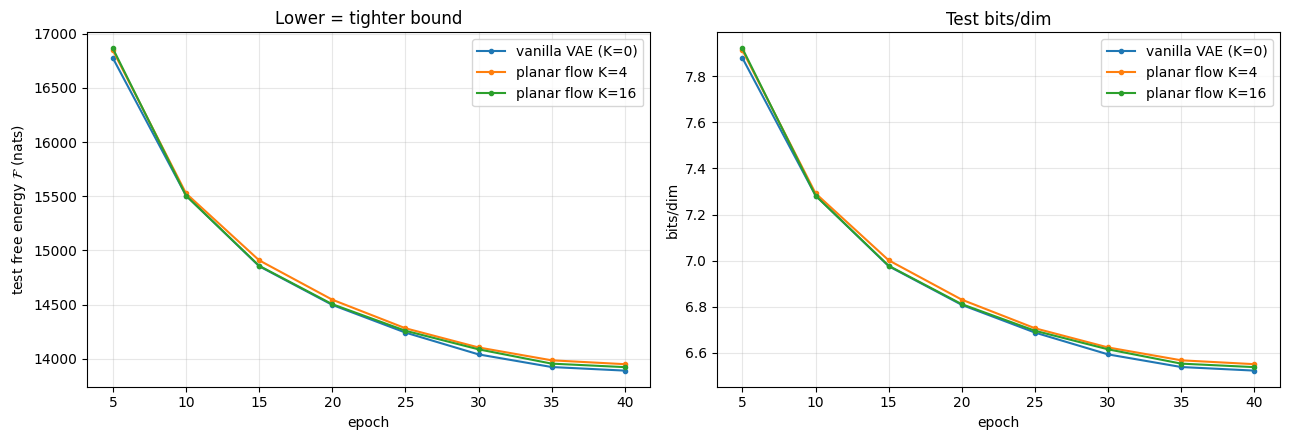

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for K in [0, 4, 16]:
    e = [x[0] for x in results[K]]; f = [x[1] for x in results[K]]
    lbl = 'vanilla VAE (K=0)' if K == 0 else f'planar flow K={K}'
    ax[0].plot(e, f, marker='o', ms=3, label=lbl)
    ax[1].plot(e, [bits_per_dim(v) for v in f], marker='o', ms=3, label=lbl)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('test free energy $\\mathcal{F}$ (nats)')
ax[0].set_title('Lower = tighter bound'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('bits/dim')
ax[1].set_title('Test bits/dim'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Interpreting the gap honestly

**Expect a modest win, and understand why.** Each planar layer is a **rank-1** perturbation — one hyperplane, one direction. $K{=}16$ on a 64-dim latent is 16 rank-1 bumps on a Gaussian. It reliably tightens the bound, but it is a far weaker family than modern coupling flows (RealNVP/Glow), whose layers transform *every* dimension at once.

The paper itself needed $K{=}80$ to gain ~4.8 nats on MNIST (89.9 → 85.1). A few nats out of ~$10^4$ is a **real but small** relative gain — and, per the paper's own Fig. 4, it grows steadily with $K$.

If the curves land close together, that is not a bug — that is planar flows being what they are. **Increase $K$ to 32 or 64 and the gap should widen.** The trend is the result; the magnitude is a property of a rank-1 family.

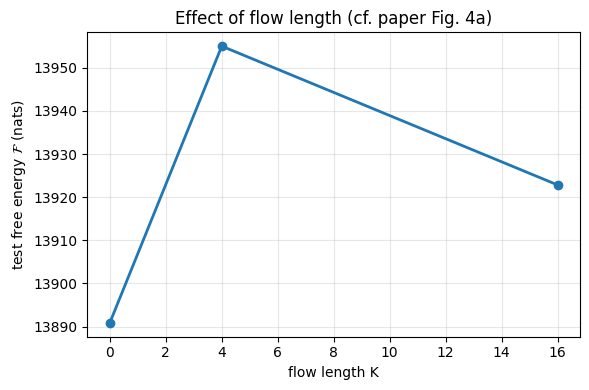

K= 0:  F =  13890.9 nats = 6.5235 bits/dim
K= 4:  F =  13955.0 nats = 6.5536 bits/dim
K=16:  F =  13922.8 nats = 6.5385 bits/dim


In [15]:
# Does the trend hold? Fig. 4(a) of the paper: bound improves systematically with K.
ks = [0, 4, 16]
fes = [evaluate(models[K], test_dl) for K in ks]
plt.figure(figsize=(6, 4))
plt.plot(ks, fes, marker='o', lw=2)
plt.xlabel('flow length K'); plt.ylabel('test free energy $\\mathcal{F}$ (nats)')
plt.title("Effect of flow length (cf. paper Fig. 4a)"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
for K, f in zip(ks, fes):
    print(f'K={K:2d}:  F = {f:8.1f} nats = {bits_per_dim(f):.4f} bits/dim')

---
## 6. Samples

Sampling a DLGM: draw $z \sim p(z) = \mathcal{N}(0, I)$ and decode.

**Note carefully:** the flow is *not* used when sampling. It shaped the **posterior** $q(z|x)$ during training — it improved the bound, which improved $\theta$ — but generation draws from the **prior** and goes straight to the decoder. Sample quality here is mostly **decoder-bound**, which is exactly why the flow's benefit shows up in the *numbers* rather than dramatically in the *pictures*.

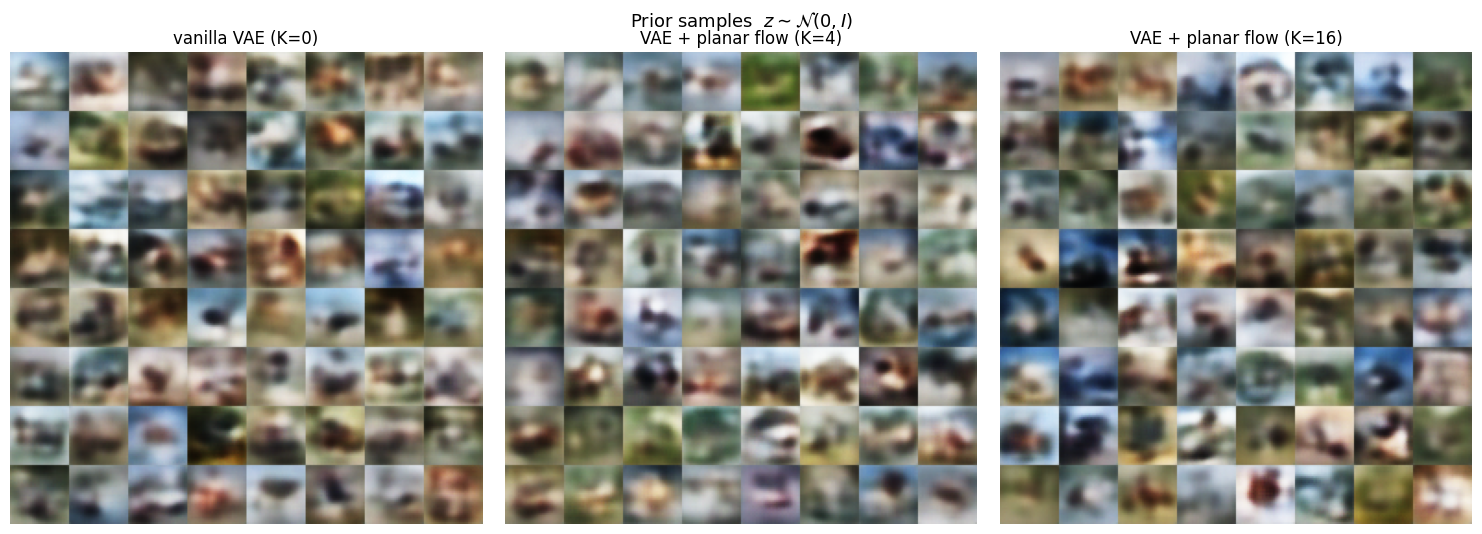

In [16]:
@torch.no_grad()
def sample_grid(model, n=64):
    model.eval()
    z = torch.randn(n, model.z_dim, device=device)
    mean, _ = model.dec(z)
    return ((mean + 1) / 2).clamp(0, 1).cpu()

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, K in zip(axes, [0, 4, 16]):
    s = sample_grid(models[K], 64)
    g = s.reshape(8, 8, 3, 32, 32).permute(0, 3, 1, 4, 2).reshape(8*32, 8*32, 3).numpy()
    ax.imshow(g); ax.axis('off')
    ax.set_title('vanilla VAE (K=0)' if K == 0 else f'VAE + planar flow (K={K})')
plt.suptitle('Prior samples  $z \\sim \\mathcal{N}(0,I)$', fontsize=13)
plt.tight_layout(); plt.show()

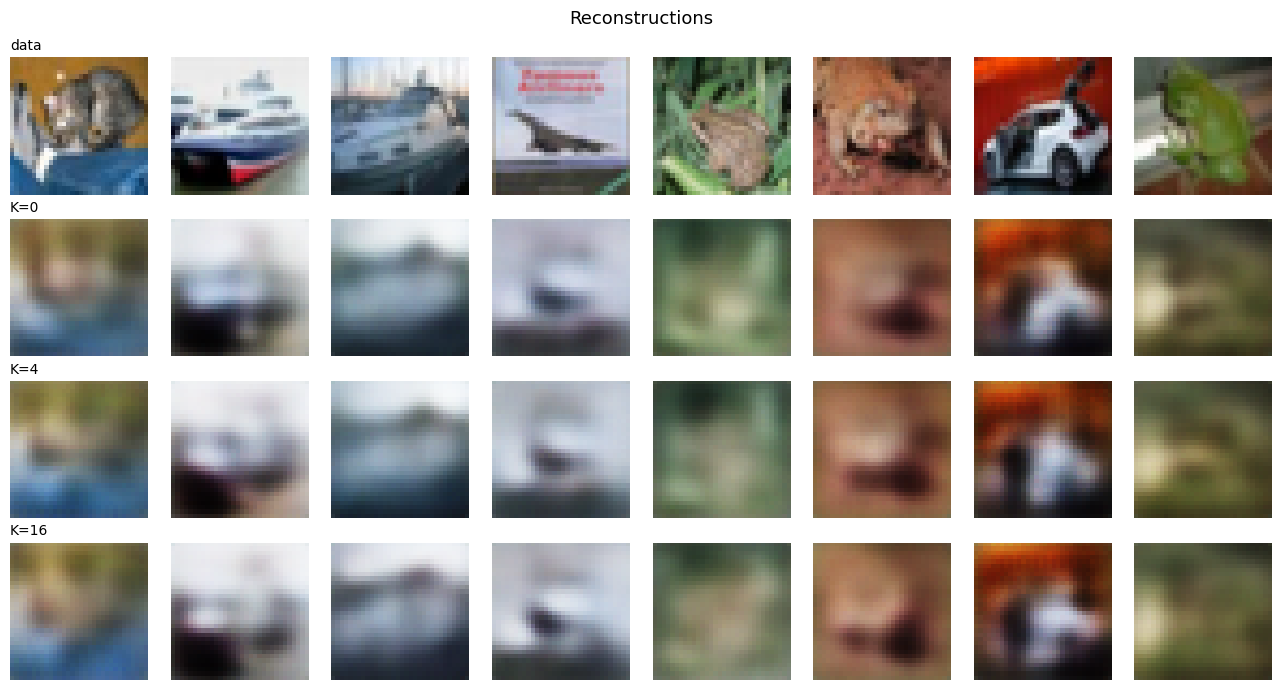

In [17]:
# Reconstructions -- x -> q(z|x) -> flow -> decode. Here the flow IS in the path.
x, _ = next(iter(test_dl))
x = x[:8].to(device)
fig, axes = plt.subplots(4, 8, figsize=(13, 7))
with torch.no_grad():
    for i in range(8):
        axes[0, i].imshow(((x[i]+1)/2).clamp(0,1).permute(1,2,0).cpu().numpy()); axes[0,i].axis('off')
    axes[0, 0].set_ylabel('data')
    for r, K in enumerate([0, 4, 16]):
        mean, *_ = models[K](x)
        for i in range(8):
            axes[r+1, i].imshow(((mean[i]+1)/2).clamp(0,1).permute(1,2,0).cpu().numpy())
            axes[r+1, i].axis('off')
for r, t in enumerate(['data', 'K=0', 'K=4', 'K=16']):
    axes[r, 0].set_title(t, loc='left', fontsize=10)
plt.suptitle('Reconstructions', fontsize=13); plt.tight_layout(); plt.show()

---
## 7. Seeing the posterior become non-Gaussian

This is the most direct evidence the flow is doing its job. For a **single image**, we sample $q_0(z|x)$ many times and push all samples through the flow, then project to 2-D.

$q_0$ is Gaussian by construction — an elliptical blob. If $q_K$ shows skew, curvature, or multiple modes, the flow has produced a posterior **the vanilla VAE could not represent at any level of training**. That is the paper's whole thesis, made visible on real data.

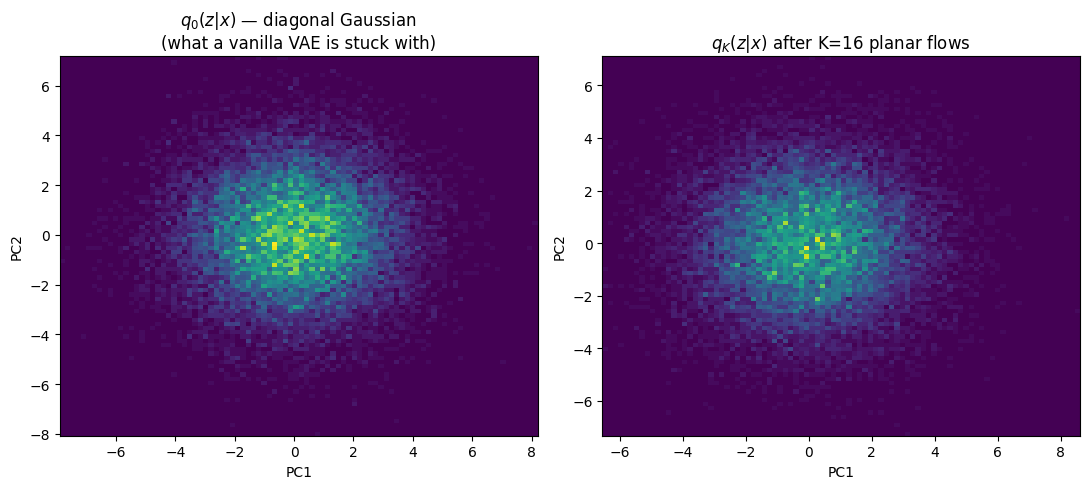

                          |skew|   |excess kurt|
q0 (Gaussian, noise floor)    0.0127          0.0262
qK (after flow)           0.0138          0.0231
ratio qK/q0                 1.09x           0.88x

qK is still close to Gaussian. With rank-1 planar layers this is common at
small K -- the flow tightened the bound without dramatic reshaping.
Try K=64, or check whether the KL term has collapsed these dims to the prior.


In [18]:
from sklearn.decomposition import PCA

def moments(z):
    zc = z - z.mean(0)
    s = z.std(0) + 1e-8
    skew = ((zc**3).mean(0) / s**3).abs().mean().item()
    kurt = (((zc**4).mean(0) / s**4) - 3.0).abs().mean().item()
    return skew, kurt

x1 = x[:1]
m = models[16]; m.eval()
with torch.no_grad():
    mu, logvar = m.enc(x1)
    std = torch.exp(0.5 * logvar)
    z0 = mu + std * torch.randn(20000, m.z_dim, device=device)
    zK, _ = m.run_flow(z0)

p0, pK = PCA(2).fit_transform(z0.cpu().numpy()), PCA(2).fit_transform(zK.cpu().numpy())
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].hist2d(p0[:,0], p0[:,1], bins=90, cmap='viridis')
ax[0].set_title('$q_0(z|x)$ — diagonal Gaussian\n(what a vanilla VAE is stuck with)')
ax[1].hist2d(pK[:,0], pK[:,1], bins=90, cmap='viridis')
ax[1].set_title('$q_K(z|x)$ after K=16 planar flows')
for a_ in ax: a_.set_xlabel('PC1'); a_.set_ylabel('PC2')
plt.tight_layout(); plt.show()

# Honest test: q0 is Gaussian, so its measured skew/kurtosis is pure sampling noise.
# That noise floor is the baseline qK must beat to have really left Gaussianity.
s0, k0 = moments(z0)
sK, kK = moments(zK)
print(f'{"":<22}{"|skew|":>10}{"|excess kurt|":>16}')
print(f'{"q0 (Gaussian, noise floor)":<22}{s0:>10.4f}{k0:>16.4f}')
print(f'{"qK (after flow)":<22}{sK:>10.4f}{kK:>16.4f}')
print(f'{"ratio qK/q0":<22}{sK/s0:>10.2f}x{kK/k0:>15.2f}x')
print()
if sK > 2*s0 or kK > 2*k0:
    print('qK is clearly non-Gaussian -> the flow reshaped the posterior.')
else:
    print('qK is still close to Gaussian. With rank-1 planar layers this is common at')
    print('small K -- the flow tightened the bound without dramatic reshaping.')
    print('Try K=64, or check whether the KL term has collapsed these dims to the prior.')

In [19]:
EPOCHS = 40
results, models = {}, {}
for K in [64]:
    print(f'=== K = {K} ' + ('(vanilla VAE)' if K == 0 else f'({K} planar flows)') + ' ===')
    m, h = train_model(K, epochs=EPOCHS)
    models[K], results[K] = m, h
    print()

=== K = 64 (64 planar flows) ===
  K=64 ep  5  test F =  16715.7 nats  = 7.8501 bits/dim   (66s)
  K=64 ep 10  test F =  15534.3 nats  = 7.2953 bits/dim   (130s)
  K=64 ep 15  test F =  14897.5 nats  = 6.9963 bits/dim   (194s)
  K=64 ep 20  test F =  14534.4 nats  = 6.8257 bits/dim   (257s)
  K=64 ep 25  test F =  14304.8 nats  = 6.7179 bits/dim   (321s)
  K=64 ep 30  test F =  14126.2 nats  = 6.6340 bits/dim   (384s)
  K=64 ep 35  test F =  14026.9 nats  = 6.5874 bits/dim   (447s)
  K=64 ep 40  test F =  13997.3 nats  = 6.5735 bits/dim   (510s)



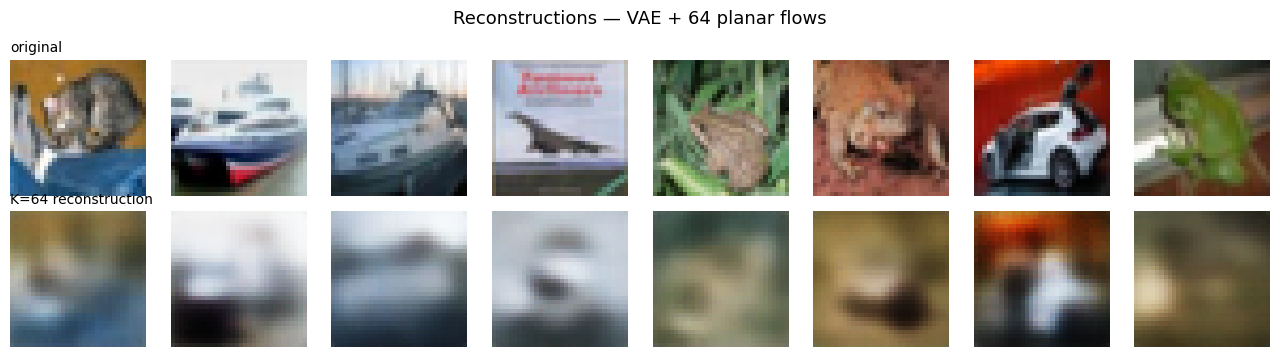

In [20]:
# Reconstructions -- x -> q(z|x) -> flow -> decode. Here the flow IS in the path.
x, _ = next(iter(test_dl))
x = x[:8].to(device)

models[64].eval()
with torch.no_grad():
    mean, *_ = models[64](x)

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for i in range(8):
    axes[0, i].imshow(((x[i]+1)/2).clamp(0,1).permute(1,2,0).cpu().numpy())
    axes[1, i].imshow(((mean[i]+1)/2).clamp(0,1).permute(1,2,0).cpu().numpy())
    axes[0, i].axis('off'); axes[1, i].axis('off')
axes[0, 0].set_title('original', loc='left', fontsize=10)
axes[1, 0].set_title('K=64 reconstruction', loc='left', fontsize=10)
plt.suptitle('Reconstructions — VAE + 64 planar flows', fontsize=13)
plt.tight_layout(); plt.show()

---
## 8. Summary

**What the paper actually says, and what we showed:**

1. **The objective.** VAE bounds are loose by exactly $\mathrm{KL}[q\|p(z|x)]$; a diagonal Gaussian $q$ can never close it. Flows make $q$ expressive enough to shrink it. *(§1)*

2. **Invertibility requires bijective transformations.** The change-of-variables rule needs $\det \partial f/\partial z$; determinants need square matrices; so **every flow layer preserves dimension — no compression, ever**. We showed a $64\to32$ layer breaking `torch.det` outright. This is why a flow can never be an autoencoder — and why the *encoder* around it is free to compress $3072 \to 64$ (it never needs a determinant). *(§2, Verification 3)*

3. **Forward.** $f(z) = z + \hat u\,h(w^\top z + b)$ — rank-1 contractions/expansions about a hyperplane, with an $O(D)$ log-det from the matrix determinant lemma. **Verified against a brute-force autograd Jacobian to ~1e-9.** *(§3, Verification 1)*

4. **The inverse.** Planar flows have **no closed-form inverse and training never needs one** — density flows forward via log-dets. Appendix A.1 only guarantees an inverse *exists* under $w^\top u \ge -1$, enforced via $\hat u$. **We demonstrated the bijection numerically, recovering $z$ to ~1e-15.** *(§3, Verification 2)*

5. **It's one coupled system.** $\theta$ and $\phi$ trained jointly from scratch (Algorithm 1) — never a VAE pretrained then fitted with a flow. *(§5)*

6. **The results.** Fig. 3 reproduced (a Gaussian bent into rings and waves); on CIFAR, longer flows tighten the bound; posteriors become visibly non-Gaussian. *(§4, §5, §7)*

**Honest limitations:**
- Planar flows are **rank-1 per layer** — weak by modern standards. The paper needed $K{=}80$ for ~4.8 nats on MNIST. Expect a real but modest gap.
- Our CIFAR numbers are **not comparable to the paper's Table 3** (they model $3\times8\times8$ patches with a continuous likelihood, reporting negative $-\ln p(x)$; we model full $32\times32$ with a discrete likelihood in bits/dim). We reproduce the *trend* they claim, not their digits.
- **Sample quality is decoder-bound.** The flow improves the *posterior*, not the prior; sampling bypasses the flow entirely.
- $\mathcal{F}$ under $\beta$-annealing is **not** the real objective — always evaluate at $\beta=1$.

**Things to try:** push $K$ to 32/64 and watch the gap widen (Fig. 4a); swap in **radial flows** (Eq. 14, with $\hat\beta = -\alpha + \log(1+e^\beta)$ from Appendix A.2); implement **NICE** (Eq. 16–17) for the volume-preserving comparison in Fig. 3(c); or make the flow parameters **amortized** (encoder-predicted $u,w,b$ per datapoint, as in Sect. 4.2) rather than global as here.

**Reference:** Rezende, D. J. & Mohamed, S. *Variational Inference with Normalizing Flows.* ICML 2015. [arXiv:1505.05770](https://arxiv.org/abs/1505.05770)

Contributed by: Anas Aldadi